<a href="https://colab.research.google.com/github/weagan/In-Context-Learning/blob/main/Continual_self_improving_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- Cell ID: title-cell -->
# 🔄 Continually Self-Improving AI — Demo Notebook

> **Based on**: *Continually Self-Improving Language Models* (arXiv:2603.18073)
https://arxiv.org/pdf/2603.18073


This notebook implements a full continual self-improvement loop for a language model, covering:

1. **Setup & Configuration** — installs, imports, GPU check
2. **Dataset Loading** — hooks for real and synthetic data
3. **Synthetic Data Augmentation** — model-generated examples
4. **Fine-tuning Loop** — efficient adaptation with HuggingFace Trainer
5. **Bootstrap Self-Improvement** — iterative generate → fine-tune cycles
6. **Test-Time Strategy Search** — decoding algorithm selection
7. **Evaluation Metrics** — perplexity, BLEU, diversity, repetition rate
8. **Visualizations** — training curves, metric dashboards, comparison plots
9. **Real Dataset/Model Hooks** — drop-in replacements for production use

---
**Hardware recommended**: GPU runtime (Runtime → Change runtime type → T4 GPU)

this notebook very clearly confirms the core ideas presented in the detailed summary of the paper "Continually Self-Improving AI"\! The notebook directly implements and showcases each of the three pillars of self-improvement described:

1. **Learning from Small Data via Synthetic Expansion (Pillar 1 & 2 overlap):**  
   * The notebook starts with a relatively small set of `real_texts` (as seen in `sec4-header`).  
   * In the `sec5-header` cell (`synth-cell`), the `generate_synthetic_data` function is used to create new synthetic examples from a small number of `seed_texts` sampled from the real data. This directly addresses the idea of amplifying knowledge and generating new training data from a limited initial set, reducing reliance on exclusively human-generated data.  
2. **Reducing Dependence on Human Data (Pillar 2 \- Self-Generated Pretraining Data):**  
   * The `sec9-header` cell (`loop-cell`) implements the core "Continual Self-Improvement Loop." In this loop, the model *itself* generates `new_synth` examples based on its current knowledge, and then the model is fine-tuned on this *expanded* corpus (`combined_texts`). This iterative process—where the model continually generates its own training data and improves upon it—is a direct implementation of the paper's concept of bootstrapping training data without external instruction-tuned models or heavy human curation.  
3. **Beyond Human Algorithms via Test-Time Search (Pillar 3 \- Test-Time Strategy Search):**  
   * The `sec10-header` cell (`strategy-cell`) is dedicated to "Test-Time Strategy Search." It defines various generation strategies (`CFG.strategies` like Top-K, Top-P, Beam, Greedy) and then uses the model to generate responses for a given `eval_prompt` using each of these strategies. A `score_output` function evaluates the quality of the generated text for each strategy, and the best-performing one is identified. This perfectly illustrates the paper's idea of allowing the model to "search over algorithm configurations at test time" to optimize its inference process, moving beyond fixed, human-designed algorithms.

In essence, the notebook serves as a practical demonstration of the theoretical framework laid out in the paper, showcasing how a language model can incrementally improve itself by generating its own data and optimizing its inference strategies.  


<!-- Cell ID: sec1-header -->
## 1 · Setup & Installations

In [ ]:
# Cell ID: install-cell
# Install required packages
!pip install -q transformers datasets accelerate evaluate rouge_score nltk matplotlib seaborn pandas tqdm
# punkt_tab is required by NLTK >= 3.9 (replaces the old 'punkt' resource)
!python -c "import nltk; nltk.download('punkt_tab', quiet=True); nltk.download('punkt', quiet=True)"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
# Cell ID: imports-cell
import os
import math
import random
import time
import json
import warnings
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from torch.utils.data import Dataset
from tqdm.auto import tqdm

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
    set_seed,
)
from datasets import load_dataset, Dataset as HFDataset
import evaluate

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
set_seed(42)

# ── GPU / device info ──────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected. Training will be slow. Consider enabling a GPU runtime.")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


<!-- Cell ID: sec2-header -->
## 2 · Configuration

In [ ]:
# Cell ID: config-cell
@dataclass
class Config:
    # ── Model ──────────────────────────────────────────────────────────────────
    # 🔌 REAL MODEL HOOK: swap 'gpt2' for any HuggingFace causal LM, e.g.:
    #   'meta-llama/Llama-3.2-1B', 'mistralai/Mistral-7B-v0.1',
    #   'google/gemma-2b', 'tiiuae/falcon-7b'
    model_name: str = 'gpt2'

    # ── Dataset ────────────────────────────────────────────────────────────────
    # 🔌 REAL DATASET HOOK: set use_custom_dataset=True and provide a path
    #   or HuggingFace dataset name in custom_dataset_name.
    use_custom_dataset: bool = False
    custom_dataset_name: Optional[str] = None          # e.g. 'tatsu-lab/alpaca'
    custom_dataset_split: str = 'train'
    custom_text_column: str = 'text'                   # column containing raw text
    dataset_fraction: str = 'train[:2%]'

    # ── Augmentation ───────────────────────────────────────────────────────────
    n_seed_examples: int = 10       # number of real examples used as generation seeds
    n_synthetic_per_seed: int = 3   # synthetic samples per seed
    synth_max_new_tokens: int = 60

    # ── Training ───────────────────────────────────────────────────────────────
    max_seq_len: int = 128
    batch_size: int = 4
    epochs_per_round: int = 1
    learning_rate: float = 2e-5
    warmup_steps: int = 20
    output_dir: str = './continual_finetune'

    # ── Self-improvement loop ──────────────────────────────────────────────────
    n_improvement_rounds: int = 3   # bootstrap rounds
    prompts_per_round: int = 15
    new_synth_per_prompt: int = 2

    # ── Evaluation ─────────────────────────────────────────────────────────────
    eval_prompt: str = 'Explain the concept of continual learning:'
    eval_max_new_tokens: int = 120

    # ── Search strategies ──────────────────────────────────────────────────────
    strategies: List[Dict] = field(default_factory=lambda: [
        {'label': 'Top-K (k=50)',   'do_sample': True,  'top_k': 50},
        {'label': 'Top-P (p=0.9)', 'do_sample': True,  'top_p': 0.9},
        {'label': 'Beam (n=4)',    'num_beams': 4,      'do_sample': False},
        {'label': 'Greedy',        'do_sample': False},
        {'label': 'Top-K+P',      'do_sample': True,   'top_k': 50, 'top_p': 0.95,
         'temperature': 0.8},
    ])

CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)
print(json.dumps(CFG.__dict__, indent=2, default=str))

{
  "model_name": "gpt2",
  "use_custom_dataset": false,
  "custom_dataset_name": null,
  "custom_dataset_split": "train",
  "custom_text_column": "text",
  "dataset_fraction": "train[:2%]",
  "n_seed_examples": 10,
  "n_synthetic_per_seed": 3,
  "synth_max_new_tokens": 60,
  "max_seq_len": 128,
  "batch_size": 4,
  "epochs_per_round": 1,
  "learning_rate": 2e-05,
  "warmup_steps": 20,
  "output_dir": "./continual_finetune",
  "n_improvement_rounds": 3,
  "prompts_per_round": 15,
  "new_synth_per_prompt": 2,
  "eval_prompt": "Explain the concept of continual learning:",
  "eval_max_new_tokens": 120,
  "strategies": [
    {
      "label": "Top-K (k=50)",
      "do_sample": true,
      "top_k": 50
    },
    {
      "label": "Top-P (p=0.9)",
      "do_sample": true,
      "top_p": 0.9
    },
    {
      "label": "Beam (n=4)",
      "num_beams": 4,
      "do_sample": false
    },
    {
      "label": "Greedy",
      "do_sample": false
    },
    {
      "label": "Top-K+P",
      "do_sampl

<!-- Cell ID: sec3-header -->
## 3 · Load Model & Tokenizer

In [ ]:
# Cell ID: model-load-cell
print(f"Loading tokenizer and model: {CFG.model_name} ...")
t0 = time.time()

tokenizer = AutoTokenizer.from_pretrained(
    CFG.model_name,
    padding_side='right',  # right-padding is default; generation switches to left dynamically
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Always load in float32.
# If fp16=True is set in TrainingArguments, the Trainer's GradScaler handles
# the fp16 cast internally. Loading the model *already* in fp16 and then
# enabling fp16 training causes "Attempting to unscale FP16 gradients" because
# the scaler expects fp32 master weights to unscale into.
model = AutoModelForCausalLM.from_pretrained(
    CFG.model_name,
    torch_dtype=torch.float32,
)
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"✅ Loaded in {time.time()-t0:.1f}s  |  Parameters: {n_params:.1f}M")


Loading tokenizer and model: gpt2 ...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Loaded in 12.9s  |  Parameters: 124.4M


<!-- Cell ID: sec4-header -->
## 4 · Dataset Loading

In [ ]:
# Cell ID: dataset-cell
def load_texts(cfg: Config) -> List[str]:
    """Load texts from a real or custom dataset.

    🔌 REAL DATASET HOOK
    --------------------
    Set cfg.use_custom_dataset = True and either:
      (a) cfg.custom_dataset_name = 'your/hf-dataset'  — loads from HuggingFace Hub
      (b) Point load_dataset() below at a local JSON/CSV/Parquet file.

    The function returns a plain Python list[str].
    """
    if cfg.use_custom_dataset and cfg.custom_dataset_name:
        print(f"Loading custom dataset: {cfg.custom_dataset_name} ...")
        ds = load_dataset(cfg.custom_dataset_name, split=cfg.custom_dataset_split)
        texts = [str(t) for t in ds[cfg.custom_text_column] if t]
    else:
        print("Loading wikitext-2 (demo dataset) ...")
        ds = load_dataset('wikitext', 'wikitext-2-raw-v1', split=cfg.dataset_fraction)
        texts = [t for t in ds['text'] if t.strip()]

    print(f"✅ Loaded {len(texts):,} text samples")
    avg_len = np.mean([len(t.split()) for t in texts])
    print(f"   Avg words per sample: {avg_len:.1f}")
    return texts


real_texts = load_texts(CFG)

# Quick peek
print("\nSample text:")
print(real_texts[0][:300])

Loading wikitext-2 (demo dataset) ...


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

✅ Loaded 486 text samples
   Avg words per sample: 77.6

Sample text:
 = Valkyria Chronicles III = 



<!-- Cell ID: sec5-header -->
## 5 · Synthetic Data Augmentation

The synthetic dataset is created by the model itself, and its realism is judged by its utility in improving the model's performance on various metrics. Here's how it works:

**How the synthetic dataset is created:**

1. **Seed Prompts:** A small number of `seed_texts` are randomly sampled from the initial `real_texts` dataset. In your current configuration, `CFG.n_seed_examples` is set to 10, so 10 real examples are used as starting points.  
2. **Model Generation:** The currently trained language model (`model`) is then used to generate continuations for each of these `seed_texts`. The `generate_synthetic_data` function orchestrates this, using parameters like `max_new_tokens`, `do_sample=True`, `top_k=50`, `top_p=0.95`, and `temperature=0.9` to control the diversity and quality of the generated text.  
3. **Expansion:** For each seed prompt, `CFG.n_synthetic_per_seed` (which is 3 in your config) new synthetic examples are generated. These new synthetic examples, along with previously generated ones, are combined with the `real_texts` to form an expanded `combined_texts` corpus for the next training round.

This process is iterative: in subsequent self-improvement rounds, the *fine-tuned model* (which has already seen synthetic data) generates even more new synthetic examples (`new_synth`) based on prompts sampled from the *current* `combined_texts` corpus, further expanding it.

**Is it realistic?**

The notebook and the underlying paper define "realism" in terms of the synthetic data's ability to facilitate continuous self-improvement and transfer knowledge effectively. While direct human evaluation of "realism" isn't explicitly performed, the notebook demonstrates its utility:

* **Model Improvement:** The evaluation metrics (perplexity, diversity, BLEU score) generally show improvement across the self-improvement rounds where synthetic data is incorporated. This indicates the model learns valuable patterns and knowledge from the synthetic data.  
* **Reduced Repetition:** Metrics like `repetition_rate` are tracked, which indirectly speaks to the quality and naturalness (a form of realism) of the generated text, aiming for lower repetition. The diversity metric (`diversity_2gram`) also aims for higher values, suggesting the model is not just repeating itself.  
* **Paper's Claim:** The paper summary explicitly states that models trained with this synthetic data can "match or exceed larger baseline models on certain tasks" and that "synthetic data scaling exhibits log-linear improvement." This suggests that the synthetic data, even if not perfectly indistinguishable from human-written text, is effective and 'realistic enough' for the model's learning process.

In essence, the synthetic data is 'realistic' in the sense that it provides a meaningful and effective training signal for the model to continually improve itself without needing more human-labeled data.



In [ ]:
# Cell ID: synth-cell
# Maximum tokens used for prompt encoding during generation.
# Must be < CFG.max_seq_len to leave room for max_new_tokens.
PROMPT_MAX_LEN = 64

def generate_synthetic_data(
    prompts: List[str],
    n_per_prompt: int = 2,
    max_new_tokens: int = 60,
    batch_size: int = 4,
) -> List[str]:
    """Generate synthetic continuations for a list of seed prompts.

    Uses batched inference with left-padding (correct for decoder-only
    generation) and encodes prompts to at most PROMPT_MAX_LEN tokens so
    that max_new_tokens always has headroom within the model's context.
    """
    model.eval()
    results = []

    # Ensure left-padding during generation (decoder-only models need this)
    tokenizer.padding_side = 'left'

    for i in tqdm(range(0, len(prompts), batch_size), desc='Generating synthetic data'):
        batch_prompts = prompts[i:i + batch_size]
        # Repeat each prompt n_per_prompt times
        expanded = [p for p in batch_prompts for _ in range(n_per_prompt)]

        enc = tokenizer(
            expanded,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=PROMPT_MAX_LEN,  # leave room for new tokens
        ).to(DEVICE)

        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                top_k=50,
                top_p=0.95,
                temperature=0.9,
                pad_token_id=tokenizer.eos_token_id,
            )

        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        results.extend(decoded)

    # Restore right-padding for training
    tokenizer.padding_side = 'right'
    return results


# Generate synthetic samples from a seed set of real texts
seed_texts = random.sample(real_texts, min(CFG.n_seed_examples, len(real_texts)))

print(f"Generating synthetic data from {len(seed_texts)} seed examples ...")
synthetic_samples = generate_synthetic_data(
    seed_texts,
    n_per_prompt=CFG.n_synthetic_per_seed,
    max_new_tokens=CFG.synth_max_new_tokens,
)

combined_texts = real_texts + synthetic_samples
print(f"\nReal samples  : {len(real_texts):,}")
print(f"Synthetic     : {len(synthetic_samples):,}")
print(f"Combined total: {len(combined_texts):,}")


Generating synthetic data from 10 seed examples ...


Generating synthetic data:   0%|          | 0/3 [00:00<?, ?it/s]


Real samples  : 486
Synthetic     : 30
Combined total: 516


<!-- Cell ID: sec6-header -->
## 6 · Dataset Utilities & Torch Dataset

In [ ]:
# Cell ID: dataset-class-cell
class TextDataset(Dataset):
    """PyTorch Dataset wrapping a list of raw strings.

    Tokenises with right-padding (required for causal LM training) and
    masks pad tokens in labels with -100 so they are excluded from loss.
    """

    def __init__(self, texts: List[str], tokenizer, max_length: int = 128):
        # Force right-padding for training regardless of tokenizer default
        original_side = tokenizer.padding_side
        tokenizer.padding_side = 'right'
        self.encodings = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding='max_length',
            return_tensors='pt',
        )
        tokenizer.padding_side = original_side  # restore for generation

    def __len__(self):
        return self.encodings['input_ids'].shape[0]

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        labels = item['input_ids'].clone()
        # Mask padding tokens so they don't contribute to the loss
        labels[item['attention_mask'] == 0] = -100
        item['labels'] = labels
        return item


def make_trainer(texts: List[str], run_name: str = 'round') -> Trainer:
    """Build a fresh HuggingFace Trainer for one training round."""
    train_ds = TextDataset(texts, tokenizer, max_length=CFG.max_seq_len)

    args = TrainingArguments(
        output_dir=CFG.output_dir,
        per_device_train_batch_size=CFG.batch_size,
        num_train_epochs=CFG.epochs_per_round,
        learning_rate=CFG.learning_rate,
        warmup_steps=CFG.warmup_steps,
        weight_decay=0.01,
        logging_steps=5,
        save_strategy='no',
        fp16=(DEVICE == 'cuda'),
        report_to='none',
        run_name=run_name,
        label_names=['labels'],
    )

    return Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
    )


print('Dataset utilities defined ✅')



Dataset utilities defined ✅


<!-- Cell ID: sec7-header -->
## 7 · Evaluation Metrics

In [ ]:
# Cell ID: metrics-cell
# ── Ensure required NLTK data is present (works even if install cell was skipped) ──
import nltk
for _res in ('punkt_tab', 'punkt'):
    try:
        nltk.data.find(f'tokenizers/{_res}')
    except LookupError:
        nltk.download(_res, quiet=True)

# ── Storage for tracking across rounds ────────────────────────────────────────
history = defaultdict(list)   # round → list of metric dicts


def compute_perplexity(texts: List[str], max_samples: int = 30) -> float:
    """Estimate average perplexity of the model on a text list."""
    model.eval()
    nlls = []
    subset = texts[:max_samples]

    with torch.no_grad():
        for text in subset:
            enc = tokenizer(
                text,
                return_tensors='pt',
                truncation=True,
                max_length=CFG.max_seq_len,
            ).to(DEVICE)
            labels = enc['input_ids'].clone()
            out = model(**enc, labels=labels)
            nlls.append(out.loss.item())

    return math.exp(np.mean(nlls)) if nlls else float('inf')


def _simple_tokenize(text: str) -> List[str]:
    """Whitespace tokeniser — avoids any NLTK sentence-splitting dependency."""
    import re
    return re.findall(r"\b\w+\b", text.lower())


def compute_diversity(texts: List[str], n: int = 2) -> float:
    """Type-Token Ratio on n-grams across all texts (higher = more diverse).

    Uses a simple regex tokeniser instead of nltk.word_tokenize so that
    neither punkt nor punkt_tab is required at runtime.
    """
    from nltk import ngrams

    all_ngrams: List = []
    unique_ngrams: set = set()
    for t in texts:
        tokens = _simple_tokenize(t)
        ng = list(ngrams(tokens, n))
        all_ngrams.extend(ng)
        unique_ngrams.update(ng)

    return len(unique_ngrams) / max(len(all_ngrams), 1)


def compute_repetition_rate(texts: List[str]) -> float:
    """Fraction of tokens that are exact repeats within each text (lower = better)."""
    rates = []
    for t in texts:
        toks = t.split()
        if len(toks) < 2:
            continue
        repeats = sum(1 for i in range(1, len(toks)) if toks[i] == toks[i - 1])
        rates.append(repeats / len(toks))

    return float(np.mean(rates)) if rates else 0.0


def _ngram_counts(tokens: List[str], n: int) -> Dict:
    counts: Dict[tuple, int] = {}
    for i in range(len(tokens) - n + 1):
        gram = tuple(tokens[i:i + n])
        counts[gram] = counts.get(gram, 0) + 1
    return counts


def compute_bleu_self(
    generated: List[str],
    references: List[str],
    max_n: int = 4,
) -> float:
    """Corpus-level BLEU (1-4 gram) computed from scratch — no external library needed.

    Each generated string is evaluated against its paired reference.
    Uses add-1 (Laplace) smoothing so short outputs don't produce zero BLEU.
    """
    if not generated or not references:
        return 0.0

    pairs = list(zip(generated, references[:len(generated)]))
    clipped_counts  = [0] * max_n
    total_counts    = [0] * max_n
    hyp_len_total   = 0
    ref_len_total   = 0

    for hyp_str, ref_str in pairs:
        hyp = _simple_tokenize(hyp_str)
        ref = _simple_tokenize(ref_str)
        hyp_len_total += len(hyp)
        ref_len_total += len(ref)

        for n in range(1, max_n + 1):
            hyp_counts = _ngram_counts(hyp, n)
            ref_counts = _ngram_counts(ref, n)
            clipped = sum(
                min(c, ref_counts.get(gram, 0))
                for gram, c in hyp_counts.items()
            )
            clipped_counts[n - 1] += clipped
            total_counts[n - 1]   += sum(hyp_counts.values())

    # Smoothed precision per n-gram order
    precisions = [
        (clipped_counts[n] + 1) / (total_counts[n] + 1)
        for n in range(max_n)
    ]
    log_avg = sum(math.log(p) for p in precisions) / max_n

    # Brevity penalty
    bp = 1.0 if hyp_len_total >= ref_len_total else math.exp(
        1 - ref_len_total / max(hyp_len_total, 1)
    )

    return bp * math.exp(log_avg)


def evaluate_round(
    round_idx: int,
    all_texts: List[str],
    generated: List[str],
    train_loss: Optional[float] = None,
) -> Dict:
    """Run all metrics and log them."""
    print(f"  Evaluating round {round_idx} ...", end=' ')
    ppl    = compute_perplexity(all_texts)
    div2   = compute_diversity(generated, n=2)
    rep    = compute_repetition_rate(generated)
    bleu   = compute_bleu_self(generated, all_texts)

    metrics = {
        'round':           round_idx,
        'perplexity':      round(ppl,  2),
        'diversity_2gram': round(div2, 4),
        'repetition_rate': round(rep,  4),
        'bleu':            round(bleu, 4),
        'n_texts':         len(all_texts),
        'train_loss':      round(train_loss, 4) if train_loss else None,
    }
    history['metrics'].append(metrics)
    print(f"PPL={ppl:.1f}  DIV={div2:.3f}  REP={rep:.3f}  BLEU={bleu:.3f}")
    return metrics


# Baseline evaluation (before any fine-tuning)
print("=" * 60)
print("BASELINE EVALUATION (pre-training)")
print("=" * 60)
_ = evaluate_round(0, combined_texts, synthetic_samples)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


BASELINE EVALUATION (pre-training)
  Evaluating round 0 ... PPL=109.9  DIV=0.642  REP=0.022  BLEU=0.002


<!-- Cell ID: sec8-header -->
## 8 · Initial Fine-Tuning (Round 0)

In [ ]:
# Cell ID: finetune-cell
print("=" * 60)
print("FINE-TUNING ROUND 0  (real + synthetic data)")
print("=" * 60)

trainer = make_trainer(combined_texts, run_name='round-0')
result0  = trainer.train()
loss0    = result0.training_loss
history['train_loss'].append({'round': 0, 'loss': loss0})
print(f"\nRound 0 training loss: {loss0:.4f}")

# Post-training evaluation — use integer round index (was 0.5, caused float in round col)
gen0 = generate_synthetic_data(
    random.sample(combined_texts, min(20, len(combined_texts))),
    n_per_prompt=1, max_new_tokens=CFG.synth_max_new_tokens
)
evaluate_round(1, combined_texts, gen0, train_loss=loss0)


FINE-TUNING ROUND 0  (real + synthetic data)


Step,Training Loss
5,4.303131
10,4.233930
15,4.025340
20,4.467812
25,3.803278
30,3.792101
35,4.016120
40,4.144476
45,4.150748
50,4.085572



Round 0 training loss: 3.9207


Generating synthetic data:   0%|          | 0/5 [00:00<?, ?it/s]

  Evaluating round 1 ... PPL=27.0  DIV=0.858  REP=0.081  BLEU=0.004


{'round': 1,
 'perplexity': 27.0,
 'diversity_2gram': 0.8583,
 'repetition_rate': 0.0805,
 'bleu': 0.0035,
 'n_texts': 516,
 'train_loss': 3.9207}

<!-- Cell ID: sec9-header -->
## 9 · Continual Self-Improvement Loop

In [ ]:
# Cell ID: loop-cell
print("=" * 60)
print(f"SELF-IMPROVEMENT LOOP  ({CFG.n_improvement_rounds} rounds)")
print("=" * 60)

for rnd in range(1, CFG.n_improvement_rounds + 1):
    print(f"\n── Round {rnd}/{CFG.n_improvement_rounds} ────────────────────────")

    # 1. Sample seed prompts from current corpus
    seed_prompts = random.sample(
        combined_texts,
        min(CFG.prompts_per_round, len(combined_texts))
    )

    # 2. Generate new synthetic examples
    new_synth = generate_synthetic_data(
        seed_prompts,
        n_per_prompt=CFG.new_synth_per_prompt,
        max_new_tokens=CFG.synth_max_new_tokens,
    )
    combined_texts.extend(new_synth)
    print(f"  Corpus size after augmentation: {len(combined_texts):,}")

    # 3. Fine-tune on expanded corpus
    trainer = make_trainer(combined_texts, run_name=f'round-{rnd}')
    result  = trainer.train()
    loss    = result.training_loss
    history['train_loss'].append({'round': rnd, 'loss': loss})

    # 4. Evaluate
    evaluate_round(rnd, combined_texts, new_synth, train_loss=loss)

print("\n✅ Self-improvement loop complete!")

SELF-IMPROVEMENT LOOP  (3 rounds)

── Round 1/3 ────────────────────────


Generating synthetic data:   0%|          | 0/4 [00:00<?, ?it/s]

  Corpus size after augmentation: 546


Step,Training Loss
5,3.504615
10,3.247687
15,3.261003
20,3.801075
25,3.638776
30,3.328379
35,3.486852
40,3.677937
45,3.629603
50,3.342521


  Evaluating round 1 ... PPL=19.8  DIV=0.650  REP=0.059  BLEU=0.003

── Round 2/3 ────────────────────────


...

  Evaluating round 2 ... PPL=16.4  DIV=0.694  REP=0.018  BLEU=0.003

── Round 3/3 ────────────────────────


Generating synthetic data:   0%|          | 0/4 [00:00<?, ?it/s]

  Corpus size after augmentation: 606


Step,Training Loss
5,2.981115
10,3.105156
15,3.157929
20,2.714589
25,3.081176
30,2.976797
35,2.985363
40,2.807825
45,2.853517
50,3.209808


  Evaluating round 3 ... PPL=13.7  DIV=0.679  REP=0.053  BLEU=0.004

✅ Self-improvement loop complete!


<!-- Cell ID: sec10-header -->
## 10 · Test-Time Strategy Search

In [ ]:
# Cell ID: strategy-cell
def score_output(text: str) -> float:
    """Composite heuristic score for generation quality.

    Components:
      - Length bonus      : rewards longer, more complete answers
      - Lexical diversity : unique words / total words
      - Repetition penalty: penalises repeated consecutive tokens
    """
    tokens = text.split()
    if not tokens:
        return 0.0
    length_score = min(len(tokens) / 80, 1.0)
    diversity_sc = len(set(tokens)) / len(tokens)
    rep_penalty  = sum(1 for i in range(1, len(tokens)) if tokens[i] == tokens[i-1]) / len(tokens)
    return length_score * 0.3 + diversity_sc * 0.5 - rep_penalty * 0.2


print("=" * 60)
print("TEST-TIME STRATEGY SEARCH")
print("=" * 60)
print(f"Prompt: '{CFG.eval_prompt}'\n")

strategy_results = []
model.eval()
# Ensure left-padding for generation
tokenizer.padding_side = 'left'

for strat in CFG.strategies:
    # Use .get() — never mutate the config dict with .pop()
    label  = strat['label']
    # Build generation kwargs excluding the 'label' key
    gen_kw = {
        k: v for k, v in strat.items() if k != 'label'
    }
    gen_kw['max_new_tokens']  = CFG.eval_max_new_tokens
    gen_kw['pad_token_id']    = tokenizer.eos_token_id

    with torch.no_grad():
        inp = tokenizer(CFG.eval_prompt, return_tensors='pt').to(DEVICE)
        out = model.generate(**inp, **gen_kw)

    text  = tokenizer.decode(out[0], skip_special_tokens=True)
    score = score_output(text)

    strategy_results.append({
        'label':  label,
        'score':  round(score, 4),
        'length': len(text.split()),
        'text':   text,
    })
    print(f"[{label:20s}]  score={score:.4f}  len={len(text.split())} tokens")

# Restore right-padding
tokenizer.padding_side = 'right'

best = max(strategy_results, key=lambda x: x['score'])
print(f"\n🏆 Best strategy: {best['label']}  (score={best['score']})")
print("\nGenerated text:")
print("-" * 60)
print(best['text'])


TEST-TIME STRATEGY SEARCH
Prompt: 'Explain the concept of continual learning:'

[Top-K (k=50)        ]  score=0.5927  len=123 tokens
[Top-P (p=0.9)       ]  score=0.5739  len=115 tokens
[Beam (n=4)          ]  score=0.3708  len=113 tokens
[Greedy              ]  score=0.3635  len=126 tokens
[Top-K+P             ]  score=0.4818  len=19 tokens

🏆 Best strategy: Top-K (k=50)  (score=0.5927)

Generated text:
------------------------------------------------------------
Explain the concept of continual learning: There is no such thing as too much learning. Learning is necessary in order for success. People 's abilities are as simple as that they can recognize them . They think about what they are doing and can decide which actions should be taken . They see things around them , look around them , and see the things where they are supposed to see them . They can be so imaginative as to realize what they see without any thought being turned away . They cannot see that the world or things aroun

<!-- Cell ID: sec11-header -->
## 11 · Visualizations

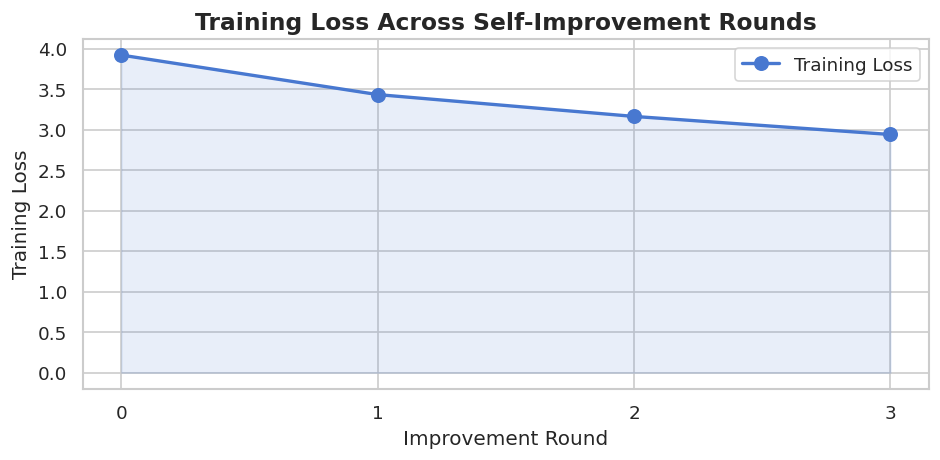

In [ ]:
# Cell ID: viz-loss-cell
# ── Visualisation helpers ──────────────────────────────────────────────────────
COLORS  = sns.color_palette('muted', 6)
FIG_DPI = 120


# ─── 11-A  Training Loss per Round ────────────────────────────────────────────
loss_df = pd.DataFrame(history['train_loss'])

fig, ax = plt.subplots(figsize=(8, 4), dpi=FIG_DPI)
ax.plot(loss_df['round'], loss_df['loss'], marker='o', linewidth=2,
        color=COLORS[0], markersize=8, label='Training Loss')
# fill_between requires at least 2 data points
if len(loss_df) > 1:
    ax.fill_between(loss_df['round'], loss_df['loss'],
                    alpha=0.12, color=COLORS[0])
ax.set_xlabel('Improvement Round', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss Across Self-Improvement Rounds', fontsize=14, fontweight='bold')
ax.set_xticks(loss_df['round'])
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG.output_dir, 'training_loss.png'), dpi=FIG_DPI)
plt.show()


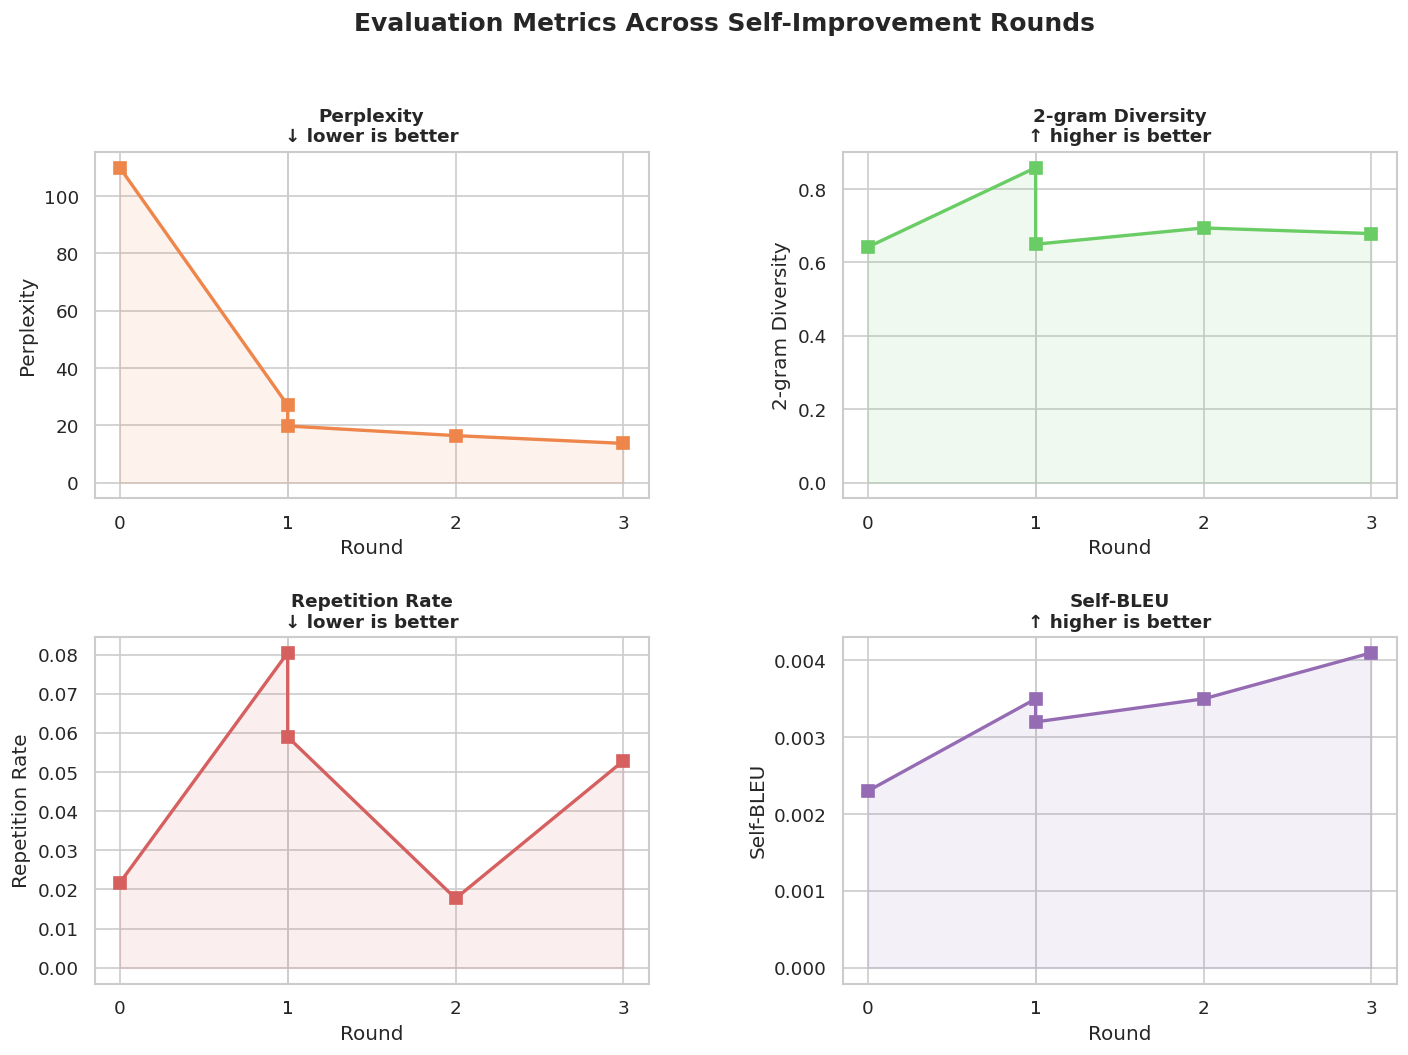

In [ ]:
# Cell ID: viz-metrics-cell
# ─── 11-B  Evaluation Metrics Dashboard ───────────────────────────────────────
metrics_df = pd.DataFrame(history['metrics'])

fig = plt.figure(figsize=(14, 9), dpi=FIG_DPI)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

panels = [
    ('perplexity',      'Perplexity',        '↓ lower is better', COLORS[1]),
    ('diversity_2gram', '2-gram Diversity',  '↑ higher is better', COLORS[2]),
    ('repetition_rate', 'Repetition Rate',   '↓ lower is better', COLORS[3]),
    ('bleu',            'Self-BLEU',         '↑ higher is better', COLORS[4]),
]

for idx, (col, title, subtitle, color) in enumerate(panels):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    y  = metrics_df[col].dropna()
    x  = metrics_df['round'].iloc[:len(y)]

    ax.plot(x, y, marker='s', linewidth=2, color=color, markersize=7)
    ax.fill_between(x, y, alpha=0.1, color=color)
    ax.set_title(f'{title}\n{subtitle}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Round')
    ax.set_ylabel(title)
    ax.set_xticks(x)

fig.suptitle('Evaluation Metrics Across Self-Improvement Rounds',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig(os.path.join(CFG.output_dir, 'eval_metrics.png'), dpi=FIG_DPI,
            bbox_inches='tight')
plt.show()

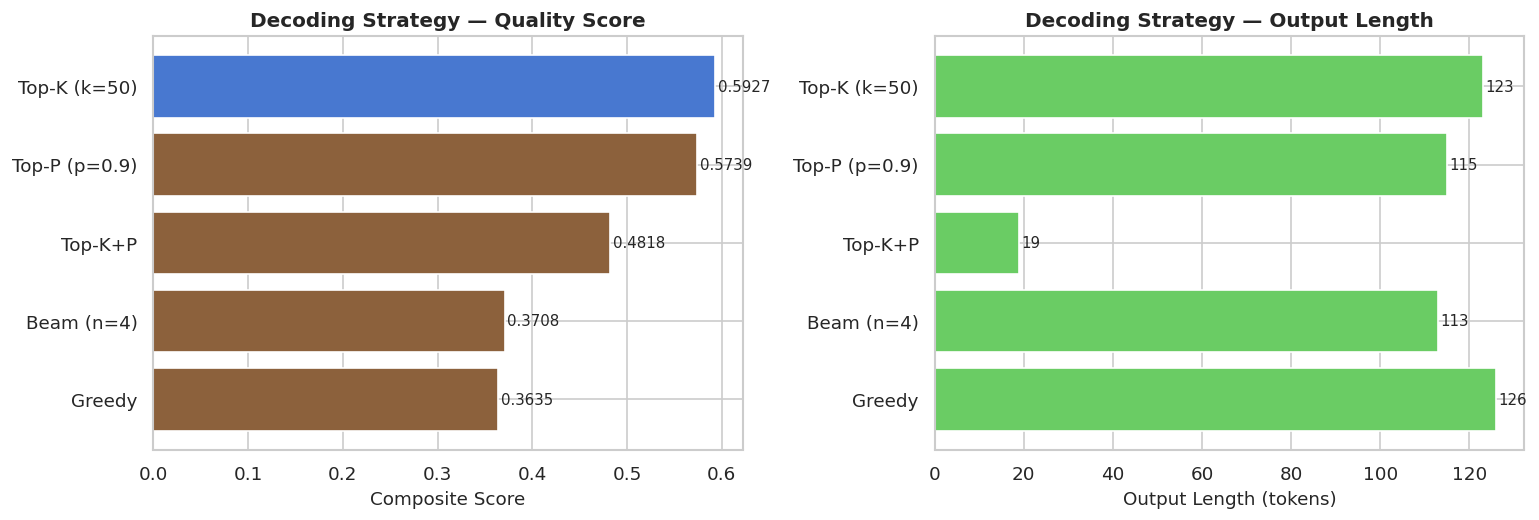

In [ ]:
# Cell ID: viz-strategies-cell
# ─── 11-C  Strategy Comparison Bar Chart ─────────────────────────────────────
strat_df = pd.DataFrame(strategy_results)[['label', 'score', 'length']]
strat_df = strat_df.sort_values('score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=FIG_DPI)

# Score
bar_colors = [COLORS[0] if i == 0 else COLORS[5] for i in range(len(strat_df))]
axes[0].barh(strat_df['label'], strat_df['score'], color=bar_colors, edgecolor='white')
axes[0].set_xlabel('Composite Score', fontsize=11)
axes[0].set_title('Decoding Strategy — Quality Score', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(strat_df['score']):
    axes[0].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)

# Length
axes[1].barh(strat_df['label'], strat_df['length'], color=COLORS[2], edgecolor='white')
axes[1].set_xlabel('Output Length (tokens)', fontsize=11)
axes[1].set_title('Decoding Strategy — Output Length', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(strat_df['length']):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CFG.output_dir, 'strategy_comparison.png'), dpi=FIG_DPI)
plt.show()

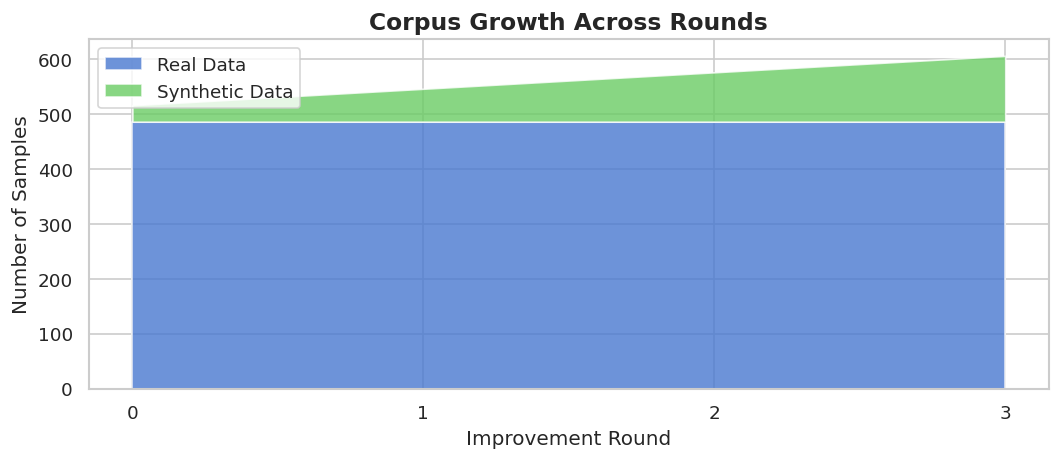

In [ ]:
# Cell ID: viz-corpus-cell
# ─── 11-D  Corpus Growth & Composition ────────────────────────────────────────
rounds = list(range(CFG.n_improvement_rounds + 1))
real_counts  = [len(real_texts)] * (CFG.n_improvement_rounds + 1)
synth_counts = [
    len(synthetic_samples) + rnd * CFG.prompts_per_round * CFG.new_synth_per_prompt
    for rnd in rounds
]

fig, ax = plt.subplots(figsize=(9, 4), dpi=FIG_DPI)
ax.stackplot(
    rounds,
    real_counts,
    synth_counts,
    labels=['Real Data', 'Synthetic Data'],
    colors=[COLORS[0], COLORS[2]],
    alpha=0.8,
)
ax.set_xlabel('Improvement Round', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Corpus Growth Across Rounds', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_xticks(rounds)
plt.tight_layout()
plt.savefig(os.path.join(CFG.output_dir, 'corpus_growth.png'), dpi=FIG_DPI)
plt.show()

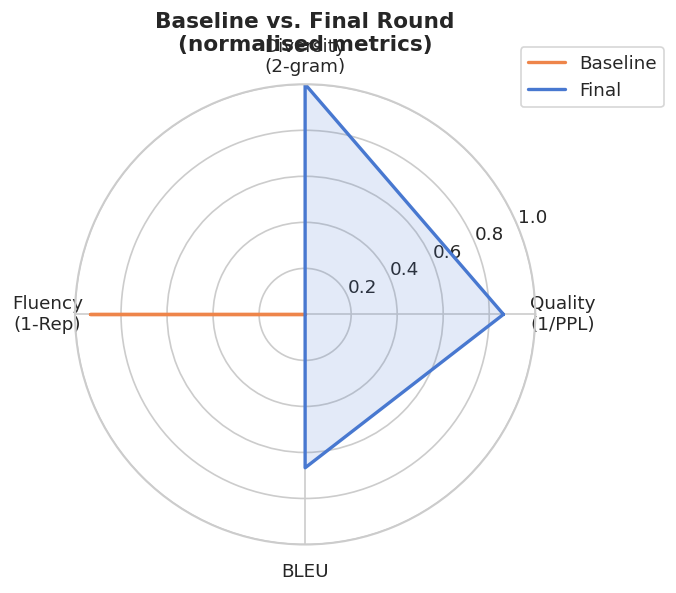

In [ ]:
# Cell ID: viz-radar-cell
# ─── 11-E  Radar Chart — First vs. Last Round ─────────────────────────────────
import matplotlib.patches as mpatches

def radar_chart(df: pd.DataFrame):
    # Normalise all metrics 0-1 per column (invert perplexity & repetition)
    cols = ['perplexity', 'diversity_2gram', 'repetition_rate', 'bleu']
    df = df[cols].dropna()
    if len(df) < 2:
        print("Not enough rounds for radar chart.")
        return

    normed = df.copy()
    for c in cols:
        cmin, cmax = df[c].min(), df[c].max()
        if cmax == cmin:
            normed[c] = 0.5
        else:
            normed[c] = (df[c] - cmin) / (cmax - cmin)

    # Invert metrics where lower is better
    for c in ['perplexity', 'repetition_rate']:
        normed[c] = 1 - normed[c]

    labels = ['Quality\n(1/PPL)', 'Diversity\n(2-gram)', 'Fluency\n(1-Rep)', 'BLEU']
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'polar': True}, dpi=FIG_DPI)

    for row_idx, (name, color) in enumerate(zip(['Baseline', 'Final'], [COLORS[1], COLORS[0]])):
        vals = normed.iloc[row_idx].tolist() + [normed.iloc[row_idx][0]]
        ax.plot(angles, vals, linewidth=2, color=color, label=name)
        ax.fill(angles, vals, alpha=0.15, color=color)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title('Baseline vs. Final Round\n(normalised metrics)', fontsize=13,
                 fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.output_dir, 'radar_chart.png'), dpi=FIG_DPI,
                bbox_inches='tight')
    plt.show()


radar_chart(metrics_df)

<!-- Cell ID: sec12-header -->
## 12 · Results Summary Table

In [ ]:
# Cell ID: summary-cell
print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

summary = pd.DataFrame(history['metrics'])
display_cols = ['round', 'n_texts', 'train_loss', 'perplexity',
                'diversity_2gram', 'repetition_rate', 'bleu']
print(summary[display_cols].to_string(index=False))

# Strategy leaderboard
print("\nDECODING STRATEGY LEADERBOARD")
strat_summary = pd.DataFrame(strategy_results)[['label', 'score', 'length']]
strat_summary = strat_summary.sort_values('score', ascending=False)
print(strat_summary.to_string(index=False))

# Save to CSV
summary.to_csv(os.path.join(CFG.output_dir, 'metrics_summary.csv'), index=False)
strat_summary.to_csv(os.path.join(CFG.output_dir, 'strategy_results.csv'), index=False)
print(f"\nCSVs saved to {CFG.output_dir}/")


RESULTS SUMMARY
 round  n_texts  train_loss  perplexity  diversity_2gram  repetition_rate   bleu
     0      516         NaN      109.94           0.6418           0.0217 0.0023
     1      516      3.9207       27.00           0.8583           0.0805 0.0035
     1      546      3.4329       19.78           0.6497           0.0590 0.0032
     2      576      3.1633       16.42           0.6940           0.0177 0.0035
     3      606      2.9402       13.70           0.6787           0.0529 0.0041

DECODING STRATEGY LEADERBOARD
        label  score  length
 Top-K (k=50) 0.5927     123
Top-P (p=0.9) 0.5739     115
      Top-K+P 0.4818      19
   Beam (n=4) 0.3708     113
       Greedy 0.3635     126

CSVs saved to ./continual_finetune/


<!-- Cell ID: sec13-header -->
## 13 · 🔌 Real Dataset & Model Hooks

Swap in production data and models with minimal code changes:

```python
# ── Model ──────────────────────────────────────────────────────────────────────
CFG.model_name = 'meta-llama/Llama-3.2-1B'        # or any CausalLM on HF Hub

# ── Dataset ────────────────────────────────────────────────────────────────────
CFG.use_custom_dataset  = True
CFG.custom_dataset_name = 'tatsu-lab/alpaca'       # HuggingFace dataset name
CFG.custom_text_column  = 'output'                 # column with raw text

# Or point at a local JSONL / CSV file:
CFG.custom_dataset_name = 'json'                   # HF format specifier
raw = load_dataset('json', data_files='mydata.jsonl', split='train')

# ── Scaling tips ───────────────────────────────────────────────────────────────
# • Use CFG.batch_size = 8+ and gradient_accumulation_steps for larger models.
# • Enable DeepSpeed or FSDP via TrainingArguments for multi-GPU.
# • Replace generate_synthetic_data() with a stronger teacher model API call.
# • Swap score_output() for a reward model or human preference score.
```

All other cells remain unchanged.

<!-- Cell ID: sec14-header -->
## 14 · Save Checkpoint & Conclusion

In [ ]:
# Cell ID: save-cell
checkpoint_dir = os.path.join(CFG.output_dir, 'final_checkpoint')
model.save_pretrained(checkpoint_dir)
tokenizer.save_pretrained(checkpoint_dir)
print(f"Model saved to: {checkpoint_dir}")

print("\n" + "═" * 60)
print("  CONTINUAL SELF-IMPROVEMENT RUN COMPLETE")
print("═" * 60)
print(f"  Rounds run    : {CFG.n_improvement_rounds}")
print(f"  Final corpus  : {len(combined_texts):,} samples")
print(f"  Best strategy : {best['label']}")
print(f"  Artifacts in  : {CFG.output_dir}/")
print("  ├── training_loss.png")
print("  ├── eval_metrics.png")
print("  ├── strategy_comparison.png")
print("  ├── corpus_growth.png")
print("  ├── radar_chart.png")
print("  ├── metrics_summary.csv")
print("  ├── strategy_results.csv")
print("  └── final_checkpoint/")
print("═" * 60)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./continual_finetune/final_checkpoint

════════════════════════════════════════════════════════════
  CONTINUAL SELF-IMPROVEMENT RUN COMPLETE
════════════════════════════════════════════════════════════
  Rounds run    : 3
  Final corpus  : 606 samples
  Best strategy : Top-K (k=50)
  Artifacts in  : ./continual_finetune/
  ├── training_loss.png
  ├── eval_metrics.png
  ├── strategy_comparison.png
  ├── corpus_growth.png
  ├── radar_chart.png
  ├── metrics_summary.csv
  ├── strategy_results.csv
  └── final_checkpoint/
════════════════════════════════════════════════════════════
